![title](imagens/cabec_08d.jpg)

## <font color='green'>Projeto 3 - Trabalhando com Datas</font>
## <font color='green'>Instalando os Pacotes e Carregando os Dados</font>

## Instalando e Carregando os Pacotes

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.11.7


In [2]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
#!pip install -q -U watermark

In [3]:
# Importação dos módulos básicos
import numpy as np
import pandas as pd
# Importação de módulo para trabalhar com datas
import datetime
# módulos para fazer os gráficos (plotagens)
import seaborn as sns
import matplotlib.pyplot as plt
# módulo para ignorar mensagens de alerta
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "pyPRO - Seja um Profissional Python!" --iversions

Author: pyPRO - Seja um Profissional Python!

matplotlib: 3.8.4
pandas    : 2.2.2
numpy     : 1.26.4
seaborn   : 0.13.2



## Carregando os Dados

### Dataset público: *Landslides After Rainfal*

Neste projeto vamos trabalhar com o dataset **"Landslides After Rainfall"** que registra os deslizamentos causados após as chuvas. De uma forma geral, deslizamentos de terra são um dos perigos mais difundidos no mundo, causando mais de 11.500 mortes em 70 países desde 2007. Saturando o solo em encostas vulneráveis, chuvas intensas e prolongadas são o gatilho de deslizamento de terra mais frequente.

Neste sentido, o Catálogo Global de Deslizamentos (GLC) foi desenvolvido para identificar eventos de deslizamentos desencadeados por chuvas em todo o mundo, independentemente do tamanho, impactos ou localização. 

O GLC considera todos os tipos de movimentos de massa desencadeados por chuvas, que foram relatados na mídia, bancos de dados de desastres, relatórios científicos ou outras fontes.  

Fonte: https://www.kaggle.com/code/rtatman/data-cleaning-challenge-parsing-dates/input?select=catalog.csv

Este arquivo estará disponível como recurso dessa aula.

In [5]:
# Criamos uma lista para identificar valores ausentes
lista_labels_valores_ausentes = ["n/a", "na", "undefined"]

In [6]:
# Carrega o dataset
deslizamentos = pd.read_csv("dados/deslizamentos.csv", na_values = lista_labels_valores_ausentes)

Vamos dar uma olhada nos dados.

In [7]:
deslizamentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1693 entries, 0 to 1692
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1693 non-null   int64  
 1   date                  1690 non-null   object 
 2   time                  629 non-null    object 
 3   continent_code        164 non-null    object 
 4   country_name          1693 non-null   object 
 5   country_code          1693 non-null   object 
 6   state/province        1692 non-null   object 
 7   population            1693 non-null   int64  
 8   city/town             1689 non-null   object 
 9   distance              1692 non-null   float64
 10  location_description  551 non-null    object 
 11  latitude              1692 non-null   float64
 12  longitude             1692 non-null   float64
 13  geolocation           1692 non-null   object 
 14  hazard_type           1693 non-null   object 
 15  landslide_type       

In [8]:
deslizamentos.head()

,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,geolocation,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,"(38.600900000000003, -77.268199999999993)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html
1,42,3/22/07,NaN,NaN,United States,US,Ohio,17288,New Philadelphia,3.33522,...,"(40.517499999999998, -81.430499999999995)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,Canton Rep.com,http://www.cantonrep.com/index.php?ID=345054&C...
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,"(40.4377, -79.915999999999997)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...
3,59,4/14/07,NaN,NaN,Canada,CA,Quebec,42786,Châteauguay,2.98682,...,"(45.322600000000001, -73.777100000000004)",Landslide,Riverbank collapse,Small,Rain,NaN,NaN,NaN,Le Soleil,http://www.hebdos.net/lsc/edition162007/articl...
4,61,4/15/07,NaN,NaN,United States,US,Kentucky,6903,Pikeville,5.66542,...,"(37.432499999999997, -82.493099999999998)",Landslide,Landslide,Small,Downpour,NaN,NaN,0.0,Matthew Crawford (KGS),NaN


In [9]:
deslizamentos.shape

(1693, 23)

In [10]:
contagem_valores_ausentes = deslizamentos.isnull().sum()
contagem_valores_ausentes[0:20]

id                         0
date                       3
time                    1064
continent_code          1529
country_name               0
country_code               0
state/province             1
population                 0
city/town                  4
distance                   1
location_description    1142
latitude                   1
longitude                  1
geolocation                1
hazard_type                0
landslide_type             1
landslide_size             1
trigger                    2
storm_name              1561
injuries                1178
dtype: int64

In [11]:
# Calculando os totais de celulas e de celulas com valores ausentes (total_nulos) ==>  DESLIZAMENTOS
total_celulas = np.prod(deslizamentos.shape)
total_nulos = contagem_valores_ausentes.sum()
# Calculando o percentual de dados ausentes em DESLIZAMENTOS
print(f"Percentual de Dados ausentes em DESLIZAMENTOS: {(total_nulos/total_celulas):.2%}")

Percentual de Dados ausentes em DESLIZAMENTOS: 19.67%


## Trabalhando com Datas

Muitos conjuntos de dados têm uma coluna de data e, às vezes, você pode ter que lidar com requisitos como buscar dados transacionais para um determinado mês ou datas de um mês. Nesses casos, você deve saber como analisar esse tipo de dado em específico... Vamos utilizar os datasets que importamos para estudar isso...

### Verificação do tipo de dados da coluna de data
Para tanto, vamos trabalhar com a coluna de data do dataframe de *deslizamentos*. A primeira coisa que vamos fazer é dar uma olhada nas primeiras linhas para ter certeza que o campo de data contém a informação que pensamos ter.

In [12]:
# mostrando as primeiras linhas da coluna de data
print(deslizamentos['date'].head())

0     3/2/07
1    3/22/07
2     4/6/07
3    4/14/07
4    4/15/07
Name: date, dtype: object


Sim, são datas! Mas só porque eu, um humano, posso dizer que são datas não significa que Python saiba que são datas. Observe que na parte inferior da saída do método head(), você pode ver que ele diz que o tipo de dados desta coluna é **"objeto"**.

O Pandas usa o tipo de dado **"objeto"** para armazenar vários tipos de dados, mas na maioria das vezes, quando você vê uma coluna com o tipo de dados "objeto", ela deverá conter *strings*.

Se você verificar a documentação do pandas sobre "dtype", notará que também há um tipo de dados específico chamado de **datetime64**. Como o tipo de dados dessa coluna é *objeto* em vez de *datetime64*, podemos dizer que o Python não sabe que esta coluna contém datas.

Também podemos ver apenas o tipo de dados dessa coluna sem imprimir as primeiras linhas, se quisermos:

In [13]:
# verificando o tipo de dados dessa coluna de data
deslizamentos['date'].dtype

dtype('O')

### Convertendo a coluna de data para *datetime*
Agora que sabemos que nossa coluna de data não está sendo reconhecida como uma data, é hora de convertê-la para que seja reconhecida como uma data. Isso é chamado de "analisar datas" porque estamos pegando uma string e identificando suas partes componentes.

Podemos definir qual é o formato de nossas datas com um guia chamado *"strftime directive"*. Para mais informações sobre diretivas de *strftime*, veja: https://strftime.org/. 

A ideia básica é que você precisa apontar quais partes da data estão onde e qual pontuação está entre elas. Existem muitas partes possíveis de uma data, mas as mais comuns são %d para dia, %m para mês, %y para um ano de dois dígitos e %Y para um ano de quatro dígitos.

Alguns exemplos:

17/01/07 tem o formato "%m/%d/%y"

17-1-2007 tem o formato "%d-%m-%Y"

Olhando para o início da coluna de data no conjunto de dados de **deslizamentos**, podemos ver que está no formato "mês/dia/ano de dois dígitos" ou seja "%m/%d/%y"...

In [14]:
# criando uma nova coluna, nova_data, com o processo de análise (parsing) de datas 
deslizamentos['nova_data'] = pd.to_datetime(deslizamentos['date'], format = "%m/%d/%y")

Agora, ao fazer a verificação das primeiras linhas da nova coluna, podemos ver que o tipo de dado é *datetime64*. 

Também podemos ver que as datas foram ligeiramente reorganizadas para que se encaixem nos objetos de data e hora padrão (ano-mês-dia).

In [15]:
# Mostrando as primeiras linhas da nova coluna de data
deslizamentos['nova_data'].head()

0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: nova_data, dtype: datetime64[ns]

Agora que as datas foram analisadas e corrigidas corretamente, podemos interagir com elas de maneira mais efetiva.

Eis uma questão que é comum que encontramos quando analisamos campos desse tipo de dados:

**E se eu encontrar um erro com vários formatos de data?**

Embora estejamos especificando o formato de data aqui, às vezes você encontrará um erro quando houver vários formatos de data em uma única coluna. Se isso acontecer, você poderá utilizar o pandas para inferir qual deve ser o formato de data correto. Você pode fazer isso assim:

deslizamentos['nova_data'] = pd.to_datetime(deslizamentos['date'], infer_datetime_format=True)

Você pode estar se perguntando... 

**Por que então não utilizar sempre infer_datetime_format = True? ***

Existem dois grandes motivos para evitar que o Pandas adivinhe o formato da data/hora: 

A primeira é que o Pandas nem sempre será capaz de descobrir o formato de data correto, especialmente se alguém for criativo com a entrada de dados. 

A segunda é que é muito mais lento do que especificar o formato exato das datas.

### Selecionando apenas o dia do mês na coluna de data
Por quê precisamos fazer todos esses ajustes nesse tipo de dados?
Para responder a essa pergunta, vamos tentar obter informações sobre o dia do mês em que ocorreu um deslizamento de terra da coluna "date" original, que possui um dtype "objeto":

In [16]:
# Tentando obter o dia de um mês da coluna "date" original
dia_do_mes_deslizamentos = deslizamentos['date'].dt.day

AttributeError: Can only use .dt accessor with datetimelike values

Como pode ser observado, ao fazermos isso, um erro é gerado! 

A parte importante a ser observada aqui é a parte no final que diz **AttributeError: Só pode usar o acessador .dt com valores semelhantes a data e hora.** 

Estamos recebendo este erro porque a função **dt.day()** não sabe como lidar com uma coluna com o tipo de dados "objeto". Mesmo que nosso dataframe tenha datas nele, porque eles não foram analisados, não podemos interagir com eles de uma forma útil.

Felizmente, temos uma coluna que analisamos anteriormente e que nos permite obter o dia do mês sem problemas ("nova_data"):

In [17]:
# Obtendo o dia de um mês da coluna "nova_data" que foi transformada para o tipo datetime
dia_do_mes_deslizamentos = deslizamentos['nova_data'].dt.day
# Mostrando os dias do mês
dia_do_mes_deslizamentos

0        2.0
1       22.0
2        6.0
3       14.0
4       15.0
        ... 
1688     7.0
1689    22.0
1690    23.0
1691    26.0
1692     2.0
Name: nova_data, Length: 1693, dtype: float64

### Plotando o dia do mês - uma análise da data
Um dos maiores perigos na análise de datas é misturar os meses e os dias. 

A função **to_datetime()** tem mensagens de erro muito úteis, mas não custa nada verificar se os dias do mês que extraímos fazem sentido.

Para fazer isso, vamos plotar um histograma dos dias do mês. 

Esperamos que tenha valores entre 1 e 31 e, como não há razão para supor que os deslizamentos de terra sejam mais comuns em alguns dias do mês do que em outros, uma distribuição relativamente uniforme. (Com uma queda em 31 porque nem todos os meses têm 31 dias.) 

Vejamos se é esse o caso:

In [18]:
qtd_na = dia_do_mes_deslizamentos.isnull().sum()
total_deslizamentos = len(dia_do_mes_deslizamentos)
percentual_na = qtd_na / total_deslizamentos
print(f"Do total de {total_deslizamentos} deslizamentos, {qtd_na} estão vazios, ou seja {percentual_na:.2%} !")

Do total de 1693 deslizamentos, 3 estão vazios, ou seja 0.18% !


<Axes: xlabel='nova_data'>

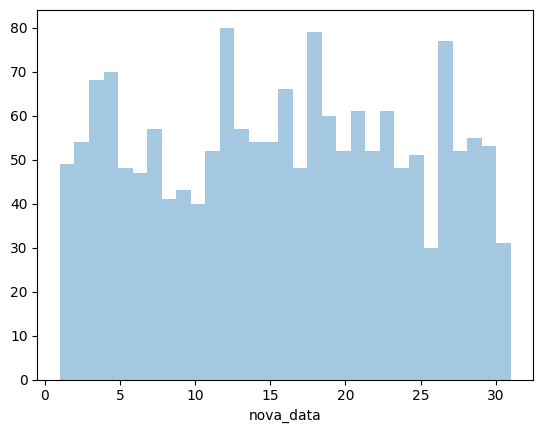

In [19]:
# Removendo todos os NaN
dia_do_mes_deslizamentos = dia_do_mes_deslizamentos.dropna()

# Plotando os dias do mês
sns.distplot(dia_do_mes_deslizamentos, kde=False, bins=31)

Sim, parece que analisamos nossas datas corretamente e este gráfico faz sentido!

# Fim Projeto 3